# 01 — RNN forecast, ignoring access types

Every row of `wiki_web_flow.csv` (desktop, mobile-web, all-access, spider…) is treated as an
independent daily-views series. The model never sees the access/agent type.

**Goal:** forecast the next 60 days of views for every row, and compare three approaches:

1. **Baseline:** median of the last 49 days
2. **GRU, naive:** every `NaN` filled with 0, no special handling
3. **GRU, missing-data plan:** `NaN` → 0 **plus** a mask channel, leading `NaN`s excluded, `NaN` targets not used in the loss

Metric: **SMAPE** (the competition metric; lower is better).

## 1. Setup and data

In [29]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

torch.manual_seed(0)
np.random.seed(0)
device = "mps" if torch.backends.mps.is_available() else "cpu"   # mps = Mac GPU
device

'mps'

In [30]:
df = pd.read_csv("data/wiki_web_flow.csv", index_col="Page")
df.columns = pd.to_datetime(df.columns)
df.shape

(145063, 803)

## 2. Missing data

From the dataset page:

> *The data source for this dataset does not distinguish between traffic values of zero and missing values.
> A missing value may mean the traffic was zero or that the data is not available for that day.*

So we **don't guess** what a `NaN` is (no interpolation). Instead:

| Rule | Why |
|---|---|
| `NaN` → 0 in the input, **plus** a 0/1 mask channel (1 = real value) | The model can tell a real 0 from a filled one and learn how much to trust gaps |
| Training windows start after the page's first real value | Leading `NaN`s mean the page didn't exist yet; they're not data |
| `NaN` target days get no weight in the loss | Don't teach the model invented values |
| `NaN` target days are skipped in SMAPE | Don't score against invented values |
| Real zeros are kept as they are | They're real data |

In [31]:
observed = df.notna().values                                  # True = real value, False = NaN
values = np.log1p(df.fillna(0).values).astype(np.float32)     # log scale tames huge spikes
raw = df.values                                               # original values (with NaN) for scoring
first_valid = observed.argmax(axis=1)                         # index of each page's first real day

n_pages, n_days = values.shape
print(f"{n_pages:,} pages x {n_days} days, {(~observed).mean():.1%} missing")

145,063 pages x 803 days, 6.0% missing


## 3. Train / validation / test split (by date)

All rows use the same cutoffs, so no series leaks future information about another.

```
|---------------- training windows ----------------|-- validation 60d --|-- test 60d --|
                                               val_start           test_start
```

- **Training:** random 180-day → 60-day windows, entirely before `val_start`
- **Validation:** used every epoch to pick the best model
- **Test:** used once at the end

In [32]:
HORIZON, LOOKBACK = 60, 180
test_start = n_days - HORIZON
val_start = test_start - HORIZON
print("validation:", df.columns[val_start].date(), "->", df.columns[test_start - 1].date())
print("test:      ", df.columns[test_start].date(), "->", df.columns[-1].date())

validation: 2017-05-14 -> 2017-07-12
test:       2017-07-13 -> 2017-09-10


## 4. Metric and baseline

In [33]:
def smape(y, yhat):
    """SMAPE in %, skipping days where the true value is NaN."""
    denom = (np.abs(y) + np.abs(yhat)) / 2
    diff = np.where(denom == 0, 0, np.abs(y - yhat) / np.where(denom == 0, 1, denom))
    return 100 * np.nanmean(np.where(np.isnan(y), np.nan, diff))

def baseline(start, window=49):
    """Median of the last `window` days, repeated for all 60 days."""
    hist = raw[:, start - window:start]
    with np.errstate(all="ignore"):
        med = np.nan_to_num(np.nanmedian(hist, axis=1))
    return np.repeat(med[:, None], HORIZON, axis=1)

results = {"baseline (median 49d)": {
    "val": smape(raw[:, val_start:test_start], baseline(val_start)),
    "test": smape(raw[:, test_start:], baseline(test_start)),
}}
results

/var/folders/sz/3_np9r_91db6_dhc9819tkwh0000gn/T/ipykernel_11674/4125644614.py:11: RuntimeWarning: All-NaN slice encountered
  med = np.nan_to_num(np.nanmedian(hist, axis=1))


{'baseline (median 49d)': {'val': np.float64(40.252718368969006),
  'test': np.float64(40.13010589400084)}}

## 5. Model

A 2-layer GRU reads the last 180 days and outputs all 60 future days at once.

Each window is shifted by the page's own average level (on the log scale), so large and small pages look
alike to the model. With the mask, the average uses real days only.

In [34]:
def make_inputs(rows, end, use_mask):
    """The 180 days before `end` -> array (..., LOOKBACK, channels)."""
    v = values[rows, end - LOOKBACK:end]
    if not use_mask:
        return v[..., None]
    m = observed[rows, end - LOOKBACK:end].astype(np.float32)
    return np.stack([v, m], axis=-1)


class WindowDataset(Dataset):
    """One random 180 -> 60 day window per page, ending before `last_day`."""
    def __init__(self, last_day, use_mask):
        rows = np.arange(n_pages)
        # earliest allowed window end: with the plan, the input must start at the first real value
        lo = first_valid + LOOKBACK if use_mask else np.full(n_pages, LOOKBACK)
        keep = lo <= last_day - HORIZON
        print(f"training pages: {keep.sum():,} (dropped {(~keep).sum():,} with too little history)")
        self.rows, self.lo = rows[keep], lo[keep]
        self.last_day, self.use_mask = last_day, use_mask

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, i):
        r = self.rows[i]
        end = np.random.randint(self.lo[i], self.last_day - HORIZON + 1)
        x = make_inputs(r, end, self.use_mask)
        return x, values[r, end:end + HORIZON], observed[r, end:end + HORIZON]


class GRUForecaster(nn.Module):
    def __init__(self, n_inputs, hidden=128, layers=2):
        super().__init__()
        self.gru = nn.GRU(n_inputs, hidden, layers, batch_first=True, dropout=0.1)
        self.head = nn.Linear(hidden, HORIZON)

    def forward(self, x):                                   # x: (batch, LOOKBACK, channels)
        v = x[..., 0]
        w = x[..., 1] if x.shape[-1] > 1 else torch.ones_like(v)   # 1 = real value
        level = (v * w).sum(1, keepdim=True) / w.sum(1, keepdim=True).clamp(min=1)
        z = ((v - level) * w).unsqueeze(-1)                 # missing days -> 0 after shifting
        out, _ = self.gru(torch.cat([z, x[..., 1:]], dim=-1))
        return self.head(out[:, -1]) + level

## 6. Training and prediction

In [35]:
@torch.no_grad()
def predict(model, end, use_mask):
    """Forecast the 60 days after `end` for every page, in views."""
    model.eval()
    x = torch.from_numpy(make_inputs(slice(None), end, use_mask))
    out = torch.cat([model(b.to(device)).cpu() for b in x.split(4096)])
    return np.expm1(out.numpy()).clip(0).round()


def train(use_mask, epochs=6, lr=1e-3):
    model = GRUForecaster(n_inputs=2 if use_mask else 1).to(device)
    loader = DataLoader(WindowDataset(val_start, use_mask), batch_size=256, shuffle=True)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    best_val, best_state = np.inf, None

    for epoch in range(epochs):
        model.train()
        total = 0
        for x, y, y_obs in loader:
            x, y = x.to(device), y.to(device)
            w = y_obs.to(device).float() if use_mask else torch.ones_like(y)   # ignore NaN targets
            loss = ((model(x) - y).abs() * w).sum() / w.sum().clamp(min=1)     # MAE on log scale ~ SMAPE
            opt.zero_grad()
            loss.backward()
            opt.step()
            total += loss.item() * len(x)

        val = smape(raw[:, val_start:test_start], predict(model, val_start, use_mask))
        print(f"epoch {epoch + 1}: train loss {total / len(loader.dataset):.3f}  val SMAPE {val:.2f}")
        if val < best_val:
            best_val = val
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)       # keep the epoch with the best validation score
    return model, best_val

### 6a. Naive: NaN → 0, no mask

In [36]:
model_naive, val = train(use_mask=False)
results["GRU, NaN -> 0"] = {"val": val, "test": smape(raw[:, test_start:], predict(model_naive, test_start, False))}

training pages: 145,063 (dropped 0 with too little history)
epoch 1: train loss 0.474  val SMAPE 39.38
epoch 2: train loss 0.455  val SMAPE 37.52
epoch 3: train loss 0.444  val SMAPE 37.55
epoch 4: train loss 0.440  val SMAPE 37.61
epoch 5: train loss 0.438  val SMAPE 37.90
epoch 6: train loss 0.433  val SMAPE 37.45


### 6b. Missing-data plan: NaN → 0 + mask, no leading NaNs, masked loss

In [37]:
model_mask, val = train(use_mask=True)
results["GRU, NaN -> 0 + mask"] = {"val": val, "test": smape(raw[:, test_start:], predict(model_mask, test_start, True))}

training pages: 142,238 (dropped 2,825 with too little history)
epoch 1: train loss 0.450  val SMAPE 37.17
epoch 2: train loss 0.429  val SMAPE 37.80
epoch 3: train loss 0.423  val SMAPE 37.26
epoch 4: train loss 0.420  val SMAPE 36.86
epoch 5: train loss 0.419  val SMAPE 37.04
epoch 6: train loss 0.417  val SMAPE 37.34


## 7. Results

In [38]:
pd.DataFrame(results).T.round(2)

,val,test
baseline (median 49d),40.25,40.13
"GRU, NaN -> 0",37.45,36.73
"GRU, NaN -> 0 + mask",36.86,36.23


## 8. Look at some forecasts

/var/folders/sz/3_np9r_91db6_dhc9819tkwh0000gn/T/ipykernel_11674/4125644614.py:11: RuntimeWarning: All-NaN slice encountered
  med = np.nan_to_num(np.nanmedian(hist, axis=1))
/var/folders/sz/3_np9r_91db6_dhc9819tkwh0000gn/T/ipykernel_11674/1089662819.py:16: UserWarning: Glyph 27744 (\N{CJK UNIFIED IDEOGRAPH-6C60}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/sz/3_np9r_91db6_dhc9819tkwh0000gn/T/ipykernel_11674/1089662819.py:16: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/sz/3_np9r_91db6_dhc9819tkwh0000gn/T/ipykernel_11674/1089662819.py:16: UserWarning: Glyph 24432 (\N{CJK UNIFIED IDEOGRAPH-5F70}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/Users/hugo/Documents/web_trafic_predictor/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 27744 (\N{CJK UNIFIED IDEOGRAPH-6C60}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io,

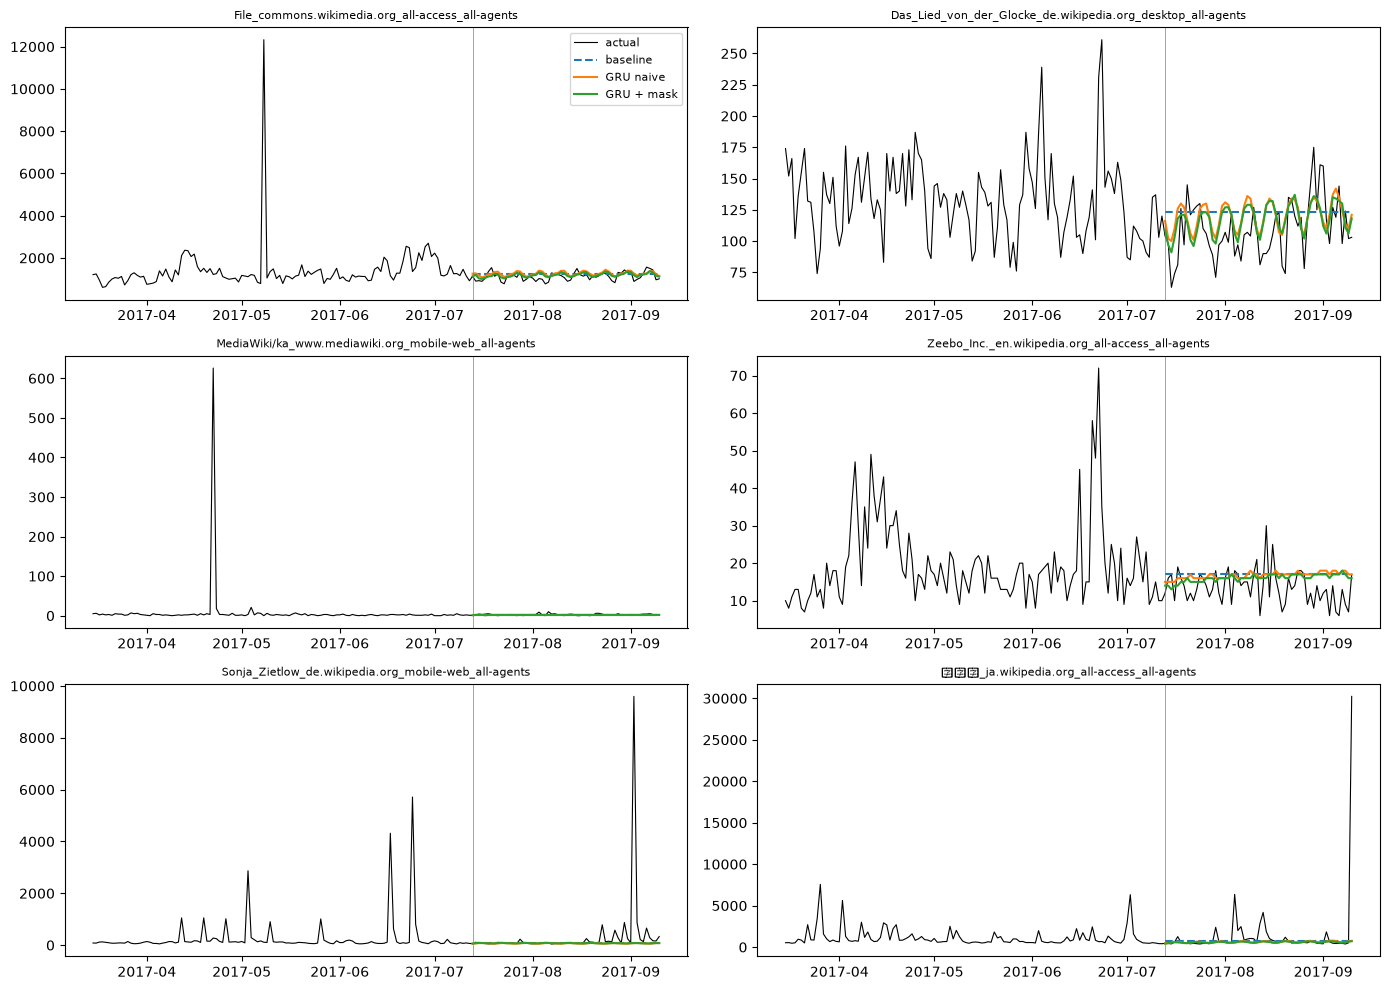

In [39]:
pred_base = baseline(test_start)
pred_naive = predict(model_naive, test_start, False)
pred_mask = predict(model_mask, test_start, True)

sample = np.random.choice(n_pages, 6, replace=False)
dates = df.columns
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
for ax, r in zip(axes.flat, sample):
    ax.plot(dates[test_start - 120:], raw[r, test_start - 120:], color="black", lw=0.8, label="actual")
    ax.plot(dates[test_start:], pred_base[r], "--", label="baseline")
    ax.plot(dates[test_start:], pred_naive[r], label="GRU naive")
    ax.plot(dates[test_start:], pred_mask[r], label="GRU + mask")
    ax.axvline(dates[test_start], color="grey", lw=0.5)
    ax.set_title(df.index[r], fontsize=8)
axes.flat[0].legend(fontsize=8)
fig.tight_layout()
plt.show()

## 9. Seasonal patterns: weekly, monthly, yearly

First check that the patterns exist, then give them to the model.

To see weekly and monthly patterns, compare each day with the page's own 28-day average around it
(this removes trends and levels). For the yearly pattern, overlay total daily views for each year.

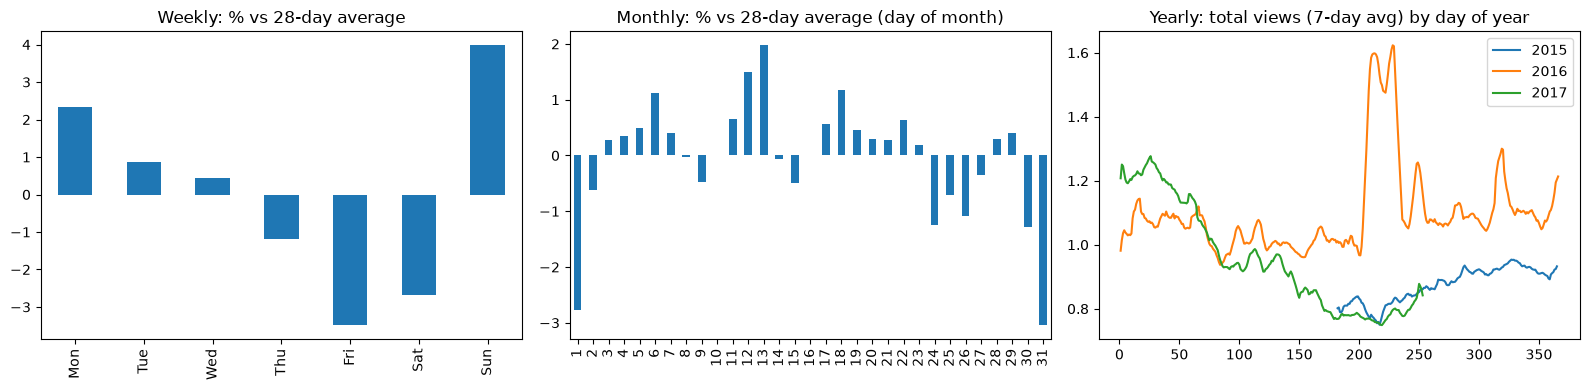

In [40]:
# 2,000 pages with no missing days, so the averages are clean
complete = np.where(observed.all(axis=1))[0]
check_rows = np.random.choice(complete, 2000, replace=False)
dates = df.columns

local_avg = pd.DataFrame(values[check_rows]).T.rolling(28, center=True, min_periods=1).mean().T.values
deviation = pd.Series((values[check_rows] - local_avg).mean(axis=0), index=dates)   # log scale
pct = lambda s: np.expm1(s) * 100                                                    # log diff -> %

weekday = pct(deviation.groupby(dates.dayofweek).mean())
weekday.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
day_of_month = pct(deviation.groupby(dates.day).mean())

total = pd.Series(np.nansum(raw, axis=0), index=dates)
total = total / total.mean()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
weekday.plot.bar(ax=axes[0], title="Weekly: % vs 28-day average")
day_of_month.plot.bar(ax=axes[1], title="Monthly: % vs 28-day average (day of month)")
for year, s in total.groupby(dates.year):
    axes[2].plot(s.index.dayofyear, s.rolling(7, min_periods=1).mean().values, label=year)
axes[2].set_title("Yearly: total views (7-day avg) by day of year")
axes[2].legend()
fig.tight_layout()
plt.show()

### How the model gets each pattern

| Pattern | Input | Why |
|---|---|---|
| **Weekly** | day-of-week as `sin`/`cos`, one pair per input day | The GRU knows which weekday each day is, and which weekday the forecast starts on |
| **Monthly** | day-of-month as `sin`/`cos` | Position in the month (start / end of month effects) |
| **Yearly** | day-of-year as `sin`/`cos` | Position in the year (summer dip, holidays…) |
| **Yearly** | **the same 60 days one year earlier** (+ their mask), given straight to the output layer | What *this page* did at this time last year: the strongest yearly signal |

`sin`/`cos` make the calendar circular: Sunday sits next to Monday, and 31 Dec next to 1 Jan.

The year-ago window uses a lag of **364 days (52 weeks)**, not 365, so the weekdays line up.

The cost: every window now needs 364 days of history, so training windows can only end from day 364
(before, from day 180). Year-ago days before a page existed are `NaN` → 0 with mask 0, like everywhere else.

In [41]:
YEAR = 364                                  # 52 weeks: same weekday one year earlier

def circular(x, period):
    angle = 2 * np.pi * np.asarray(x) / np.asarray(period)
    return np.sin(angle), np.cos(angle)

calendar = np.stack([
    *circular(dates.dayofweek, 7),                          # weekly
    *circular(dates.day - 1, dates.days_in_month),          # monthly
    *circular(dates.dayofyear - 1, 365.25),                 # yearly
], axis=1).astype(np.float32)                               # (n_days, 6)
N_CAL = calendar.shape[1]


def make_seasonal_inputs(rows, end):
    """Returns
    seq:      (..., LOOKBACK, 2 + 6)  views, mask, calendar for the 180 days before `end`
    year_ago: (..., 2 * HORIZON)      views and mask for the 60 forecast days, one year earlier
    """
    v = values[rows, end - LOOKBACK:end]
    m = observed[rows, end - LOOKBACK:end].astype(np.float32)
    cal = np.broadcast_to(calendar[end - LOOKBACK:end], v.shape + (N_CAL,))
    seq = np.concatenate([v[..., None], m[..., None], cal], axis=-1)

    yv = values[rows, end - YEAR:end - YEAR + HORIZON]
    ym = observed[rows, end - YEAR:end - YEAR + HORIZON].astype(np.float32)
    year_ago = np.concatenate([yv, ym], axis=-1)
    return seq.astype(np.float32), year_ago.astype(np.float32)


class SeasonalDataset(Dataset):
    """Random windows like before, but each also needs a full year of history before it."""
    def __init__(self, last_day):
        lo = np.maximum(first_valid + LOOKBACK, YEAR)
        keep = lo <= last_day - HORIZON
        print(f"training pages: {keep.sum():,} (dropped {(~keep).sum():,} with too little history)")
        self.rows, self.lo, self.last_day = np.arange(n_pages)[keep], lo[keep], last_day

    def __len__(self):
        return len(self.rows)

    def __getitem__(self, i):
        r = self.rows[i]
        end = np.random.randint(self.lo[i], self.last_day - HORIZON + 1)
        seq, year_ago = make_seasonal_inputs(r, end)
        return seq, year_ago, values[r, end:end + HORIZON], observed[r, end:end + HORIZON]


class SeasonalGRU(nn.Module):
    def __init__(self, hidden=128, layers=2):
        super().__init__()
        self.gru = nn.GRU(2 + N_CAL, hidden, layers, batch_first=True, dropout=0.1)
        # output layer sees: GRU memory + year-ago values + year-ago mask
        self.head = nn.Sequential(
            nn.Linear(hidden + 2 * HORIZON, hidden),
            nn.ReLU(),
            nn.Linear(hidden, HORIZON),
        )

    def forward(self, seq, year_ago):
        v, w = seq[..., 0], seq[..., 1]
        level = (v * w).sum(1, keepdim=True) / w.sum(1, keepdim=True).clamp(min=1)
        z = ((v - level) * w).unsqueeze(-1)
        out, _ = self.gru(torch.cat([z, seq[..., 1:]], dim=-1))       # mask + calendar go in unchanged

        yv, ym = year_ago[:, :HORIZON], year_ago[:, HORIZON:]
        year_z = (yv - level) * ym                                    # year-ago views, same scale as input
        return self.head(torch.cat([out[:, -1], year_z, ym], dim=-1)) + level

In [42]:
@torch.no_grad()
def predict_seasonal(model, end, batch=4096):
    """Forecast the 60 days after `end` for every page (in chunks: the inputs are big)."""
    model.eval()
    preds = []
    for start in range(0, n_pages, batch):
        seq, year_ago = make_seasonal_inputs(slice(start, start + batch), end)
        out = model(torch.from_numpy(seq).to(device), torch.from_numpy(year_ago).to(device))
        preds.append(out.cpu().numpy())
    return np.expm1(np.concatenate(preds)).clip(0).round()


def train_seasonal(epochs=6, lr=1e-3, lr_schedule=False, patience=None):
    """lr_schedule: halve the learning rate when val SMAPE stops improving.
    patience: stop after this many epochs without improvement (None = never stop early)."""
    model = SeasonalGRU().to(device)
    loader = DataLoader(SeasonalDataset(val_start), batch_size=256, shuffle=True)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, factor=0.5, patience=1) if lr_schedule else None
    best_val, best_state, bad_epochs = np.inf, None, 0

    for epoch in range(epochs):
        model.train()
        total = 0
        for seq, year_ago, y, y_obs in loader:
            seq, year_ago, y = seq.to(device), year_ago.to(device), y.to(device)
            w = y_obs.to(device).float()                                # ignore NaN targets
            loss = ((model(seq, year_ago) - y).abs() * w).sum() / w.sum().clamp(min=1)
            opt.zero_grad()
            loss.backward()
            opt.step()
            total += loss.item() * len(y)

        val = smape(raw[:, val_start:test_start], predict_seasonal(model, val_start))
        if scheduler:
            scheduler.step(val)
        print(f"epoch {epoch + 1}: train loss {total / len(loader.dataset):.3f}  val SMAPE {val:.2f}"
              f"  lr {opt.param_groups[0]['lr']:.0e}")
        if val < best_val:
            best_val, bad_epochs = val, 0
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        else:
            bad_epochs += 1
            if patience is not None and bad_epochs >= patience:
                print(f"early stop: no improvement for {patience} epochs")
                break

    model.load_state_dict(best_state)
    return model, best_val

In [43]:
model_seasonal, val = train_seasonal()
results["GRU + mask + seasonal"] = {"val": val, "test": smape(raw[:, test_start:], predict_seasonal(model_seasonal, test_start))}
pd.DataFrame(results).T.round(2)

training pages: 142,238 (dropped 2,825 with too little history)
epoch 1: train loss 0.436  val SMAPE 36.28  lr 1e-03
epoch 2: train loss 0.418  val SMAPE 36.91  lr 1e-03
epoch 3: train loss 0.408  val SMAPE 35.70  lr 1e-03
epoch 4: train loss 0.403  val SMAPE 35.83  lr 1e-03
epoch 5: train loss 0.399  val SMAPE 35.16  lr 1e-03
epoch 6: train loss 0.398  val SMAPE 35.26  lr 1e-03


,val,test
baseline (median 49d),40.25,40.13
"GRU, NaN -> 0",37.45,36.73
"GRU, NaN -> 0 + mask",36.86,36.23
GRU + mask + seasonal,35.16,35.84


### Forecasts: mask vs mask + seasonal

/var/folders/sz/3_np9r_91db6_dhc9819tkwh0000gn/T/ipykernel_11674/3191131081.py:13: UserWarning: Glyph 27744 (\N{CJK UNIFIED IDEOGRAPH-6C60}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/sz/3_np9r_91db6_dhc9819tkwh0000gn/T/ipykernel_11674/3191131081.py:13: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/var/folders/sz/3_np9r_91db6_dhc9819tkwh0000gn/T/ipykernel_11674/3191131081.py:13: UserWarning: Glyph 24432 (\N{CJK UNIFIED IDEOGRAPH-5F70}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/Users/hugo/Documents/web_trafic_predictor/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 27744 (\N{CJK UNIFIED IDEOGRAPH-6C60}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/hugo/Documents/web_trafic_predictor/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 19978 (\N{CJK UNIFIED IDEOGRAPH-4E0A}) 

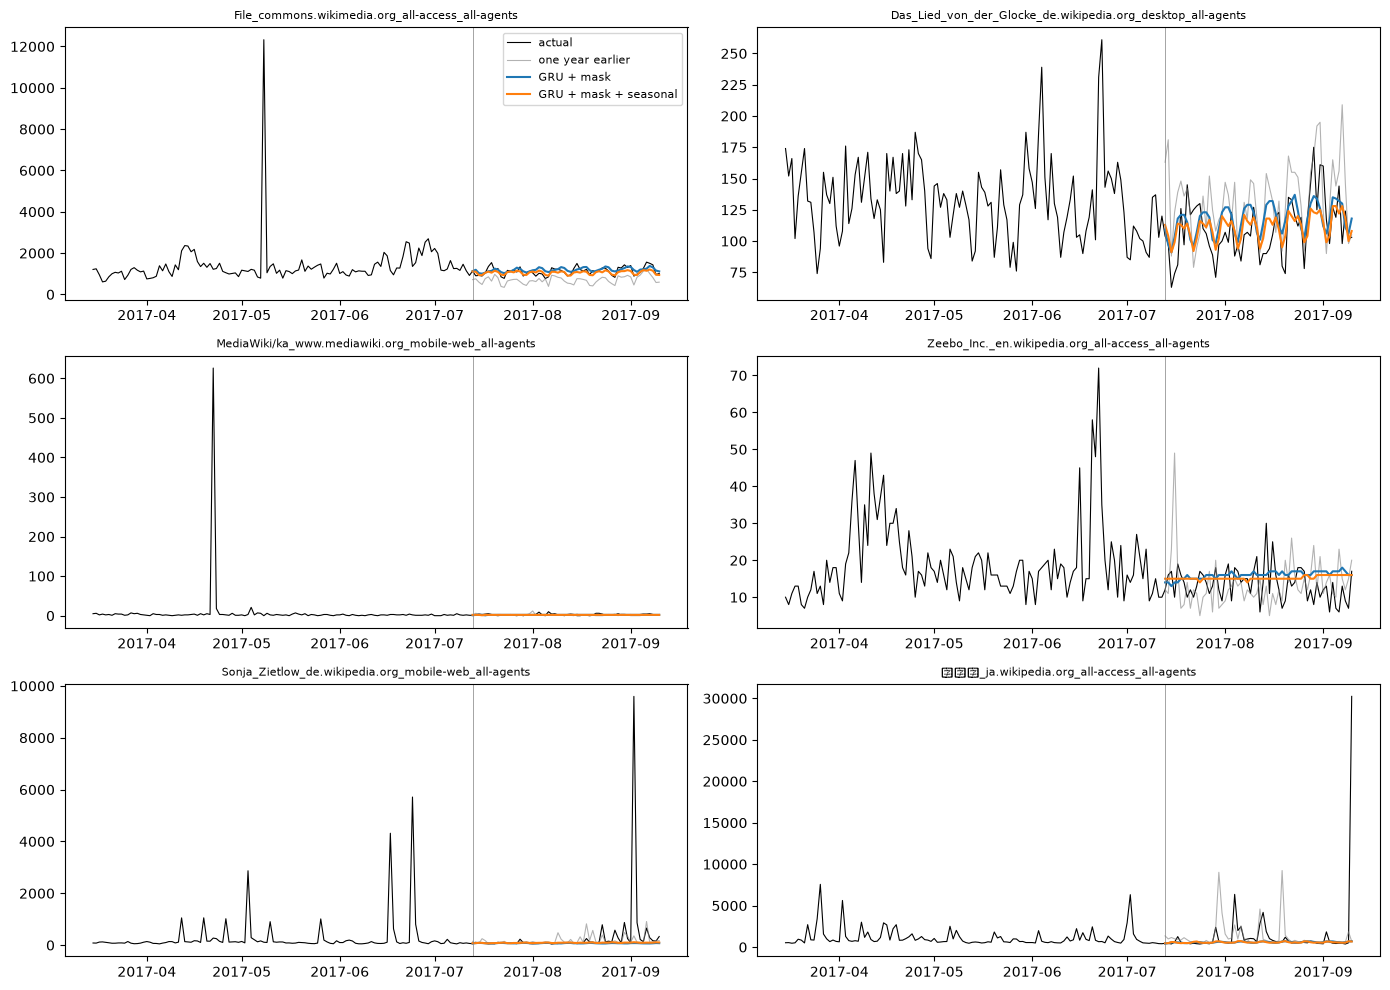

In [44]:
pred_seasonal = predict_seasonal(model_seasonal, test_start)

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
for ax, r in zip(axes.flat, sample):                   # same 6 pages as section 8
    ax.plot(dates[test_start - 120:], raw[r, test_start - 120:], color="black", lw=0.8, label="actual")
    ax.plot(dates[test_start:], raw[r, test_start - YEAR:test_start - YEAR + HORIZON],
            color="grey", lw=0.8, alpha=0.6, label="one year earlier")
    ax.plot(dates[test_start:], pred_mask[r], label="GRU + mask")
    ax.plot(dates[test_start:], pred_seasonal[r], label="GRU + mask + seasonal")
    ax.axvline(dates[test_start], color="grey", lw=0.5)
    ax.set_title(df.index[r], fontsize=8)
axes.flat[0].legend(fontsize=8)
fig.tight_layout()
plt.show()

## 10. Longer training: GRU + mask + seasonal, 30 epochs

With 6 epochs, validation SMAPE was still improving near the end (best at epoch 5).
Here: up to 30 epochs, and the learning rate is halved every time validation stalls for 2 epochs,
so late epochs make smaller, steadier steps. The best epoch (by validation) is kept.

Takes about 30 s per epoch → up to ~15 min. To stop early instead, pass e.g. `patience=5`.

In [45]:
torch.manual_seed(0)
model_seasonal_30, val = train_seasonal(epochs=30, lr_schedule=True)
results["GRU + mask + seasonal, 30 ep"] = {"val": val, "test": smape(raw[:, test_start:], predict_seasonal(model_seasonal_30, test_start))}
pd.DataFrame(results).T.round(2)

training pages: 142,238 (dropped 2,825 with too little history)
epoch 1: train loss 0.436  val SMAPE 36.51  lr 1e-03
epoch 2: train loss 0.419  val SMAPE 36.18  lr 1e-03
epoch 3: train loss 0.408  val SMAPE 35.41  lr 1e-03
epoch 4: train loss 0.404  val SMAPE 35.71  lr 1e-03
epoch 5: train loss 0.400  val SMAPE 35.15  lr 1e-03
epoch 6: train loss 0.398  val SMAPE 35.65  lr 1e-03
epoch 7: train loss 0.396  val SMAPE 35.52  lr 5e-04
epoch 8: train loss 0.391  val SMAPE 35.42  lr 5e-04
epoch 9: train loss 0.392  val SMAPE 35.22  lr 3e-04
epoch 10: train loss 0.391  val SMAPE 35.19  lr 3e-04
epoch 11: train loss 0.390  val SMAPE 35.28  lr 1e-04
epoch 12: train loss 0.390  val SMAPE 35.04  lr 1e-04
epoch 13: train loss 0.389  val SMAPE 35.14  lr 1e-04
epoch 14: train loss 0.389  val SMAPE 35.19  lr 6e-05
epoch 15: train loss 0.389  val SMAPE 35.31  lr 6e-05
epoch 16: train loss 0.389  val SMAPE 35.40  lr 3e-05
epoch 17: train loss 0.388  val SMAPE 35.32  lr 3e-05
epoch 18: train loss 0.388 

,val,test
baseline (median 49d),40.25,40.13
"GRU, NaN -> 0",37.45,36.73
"GRU, NaN -> 0 + mask",36.86,36.23
GRU + mask + seasonal,35.16,35.84
"GRU + mask + seasonal, 30 ep",35.04,35.64


## 11. Bigger lookback: 400 days, 6 epochs

So far the GRU reads the last **180 days**, and gets last year only as the 60 year-ago days at the output.
With **400 days** the GRU itself reads more than a full year, so it can see how last year's same season
*developed* (the run-up and the drop), not just the 60 days.

Same model as section 9 (GRU + mask + seasonal), only `LOOKBACK` changes. 6 epochs, like section 9, so the two
are directly comparable.

Costs:
- the GRU reads 400 steps instead of 180 → each epoch takes roughly **2× longer**
- a training window now needs 400 days of history, so windows can only end from day 400 and pages created
  later are dropped from training (the cell prints how many)

`make_seasonal_inputs`, `SeasonalDataset` and `predict_seasonal` read the global `LOOKBACK`,
so changing it here is enough. It is set back to 180 at the end so earlier sections still work if re-run.

In [ ]:
LOOKBACK = 400
torch.manual_seed(0)
np.random.seed(0)
model_seasonal_400, val = train_seasonal(epochs=6)
results["GRU + mask + seasonal, lookback 400"] = {
    "val": val,
    "test": smape(raw[:, test_start:], predict_seasonal(model_seasonal_400, test_start)),
}
LOOKBACK = 180      # back to the default for the other sections
pd.DataFrame(results).T.round(2)

training pages: 135,283 (dropped 9,780 with too little history)


## Next ideas

- Try each seasonal input on its own (weekly only, yearly only…) to see which one helps
- Clip one-day spikes before training
- Add access/agent type as inputs (next notebook)